### Задание:
**Задача 1**
Изучить таблицу users_info, содержащую информацию о пользователях. Провести разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+Сколько пропущенных значений в каждом столбце?
+ Удалить все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитть границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалить выбросы из таблицы.

**Визуализация**
+ Построить гистограмму (sns.histplot) распределения возрастов пользователей.



**Задача 2** 
Проанализировать распределение пользователей по полу и городам:
+ Рассчитать количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Использовать pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитать долю женщин среди всех пользователей.
+ Построить столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузить таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитать среднее количество тренировок в месяц для каждого пользователя.

+ Разделить пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитать, сколько пользователей входит в каждую из этих групп.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [3]:
users_info.shape

(1000, 4)

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
users_info['age'].describe()

count    912.000000
mean      39.419956
std       13.732275
min       18.000000
25%       28.000000
50%       38.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [7]:
users_info.loc[(users_info['age'].isnull()), 'age'] = 39

In [8]:
users_info = users_info[(~users_info['age'].isnull())&(~users_info['gender'].isnull())] #удалено 8.9%

In [9]:
users_info.shape

(911, 4)

In [10]:
users_info.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [11]:
Q1 = np.percentile (users_info['age'], 25)
Q3 = np.percentile (users_info['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print (lower_bound)
print (upper_bound)
out_lower = users_info[users_info['age'] < lower_bound]
out_upper = users_info[users_info['age'] > upper_bound]
print(f"Выбросы ниже нижней границы: {len(out_lower)}")
print(f"Выбросы выше верхней границы: {len(out_upper)}")

-5.0
83.0
Выбросы ниже нижней границы: 0
Выбросы выше верхней границы: 0


In [12]:
#выбросов нет

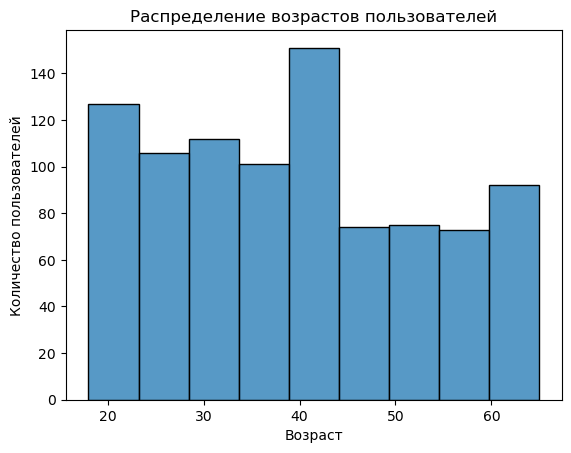

In [13]:
sns.histplot(users_info['age'], binwidth=5)
plt.title('Распределение возрастов пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

### Задача 2. Доля пользователей-женщин по городам

In [14]:
pivot_pay = users_info.pivot_table(index=['city'],      
                                        columns='gender',     
                                        values='id_user',      
                                        aggfunc=['count'],   
                                        fill_value=0).reset_index() 
pivot_pay.head()

city  count     
gender               female male
0       Екатеринбург     59   83
1             Казань     54   80
2             Москва    233  110
3                СПб    127  165

In [15]:
pivot_pay.columns = pivot_pay.columns.map('_'.join)
pivot_pay.head()

,city_,count_female,count_male
0,Екатеринбург,59,83
1,Казань,54,80
2,Москва,233,110
3,СПб,127,165


In [16]:
pivot_pay['sum_gender'] = pivot_pay['count_female']+pivot_pay['count_male']
pivot_pay['female_ratio'] = pivot_pay['count_female'] / pivot_pay['sum_gender']
pivot_pay

,city_,count_female,count_male,sum_gender,female_ratio
0,Екатеринбург,59,83,142,0.415493
1,Казань,54,80,134,0.402985
2,Москва,233,110,343,0.679300
3,СПб,127,165,292,0.434932


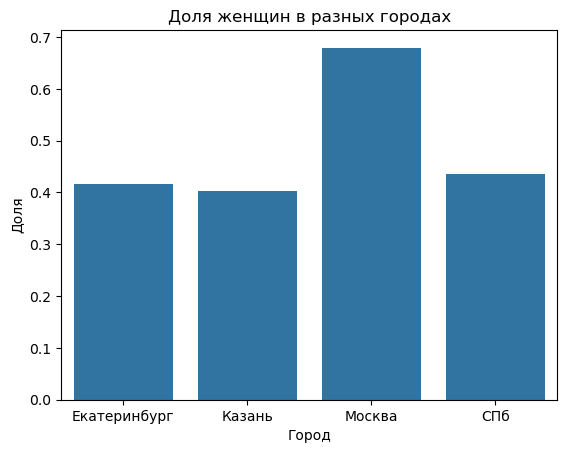

In [17]:
sns.barplot(data=pivot_pay, x='city_', y='female_ratio')
plt.title('Доля женщин в разных городах')
plt.xlabel('Город')
plt.ylabel('Доля')
plt.show()

In [18]:
#Москва выделяется среди других городов большей долей женщин

### Задача 3. Делим пользователей на бины

In [19]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head(10)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200
5,1000,2023-08,0,3,0,5400,3,5400
6,1000,2023-09,0,4,0,7200,4,7200
7,1000,2023-11,0,5,0,9000,5,9000
8,1000,2023-12,0,5,0,9000,5,9000
9,1001,2023-01,12,2,9600,3600,14,13200


In [20]:
pay_gr = pay_mon.groupby('id_user'). agg(cnt_mon = ('mon', 'count'), cnt_tren = ('cnt_total', 'sum')).reset_index()
pay_gr ['avg_tren_in_mon'] = round (pay_gr ['cnt_tren']/pay_gr ['cnt_mon'], 0)
pay_gr

,id_user,cnt_mon,cnt_tren,avg_tren_in_mon
0,1000,9,33,4.0
1,1001,11,129,12.0
2,1002,11,128,12.0
3,1003,6,31,5.0
4,1004,9,18,2.0
...,...,...,...,...
964,1994,1,7,7.0
965,1995,2,23,12.0
966,1996,2,3,2.0
967,1997,9,45,5.0


In [21]:
pay_gr['avg_tren_in_mon'].describe()

count    969.000000
mean       6.373581
std        3.571114
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       18.000000
Name: avg_tren_in_mon, dtype: float64

In [22]:
bins = [0, 5, 10, float('inf')]
labels = ['мало (редко тренируются)', 'средне', 'много (тренируются часто)']
pay_gr['group'] = pd.cut(pay_gr['avg_tren_in_mon'], bins=bins, labels=labels, right=True)
pay_gr

,id_user,cnt_mon,cnt_tren,avg_tren_in_mon,group
0,1000,9,33,4.0,мало (редко тренируются)
1,1001,11,129,12.0,много (тренируются часто)
2,1002,11,128,12.0,много (тренируются часто)
3,1003,6,31,5.0,мало (редко тренируются)
4,1004,9,18,2.0,мало (редко тренируются)
...,...,...,...,...,...
964,1994,1,7,7.0,средне
965,1995,2,23,12.0,много (тренируются часто)
966,1996,2,3,2.0,мало (редко тренируются)
967,1997,9,45,5.0,мало (редко тренируются)


In [23]:
pay_gr2 = pay_gr.groupby('group', observed=False).agg (cnt_user = ('id_user','count')).reset_index()
pay_gr2

,group,cnt_user
0,мало (редко тренируются),435
1,средне,400
2,много (тренируются часто),134


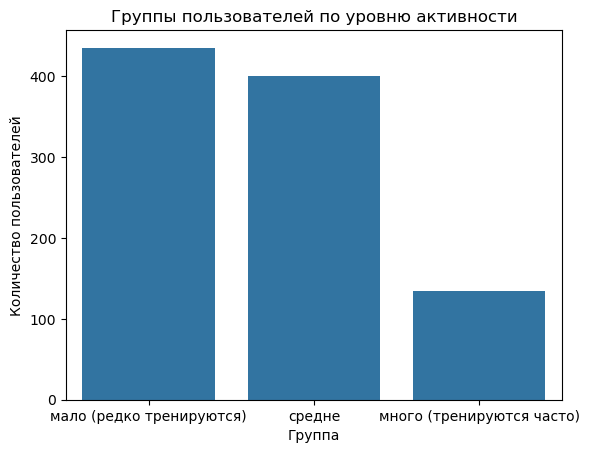

In [24]:
sns.barplot(data=pay_gr2, x='group', y='cnt_user')
plt.title('Группы пользователей по уровню активности')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()